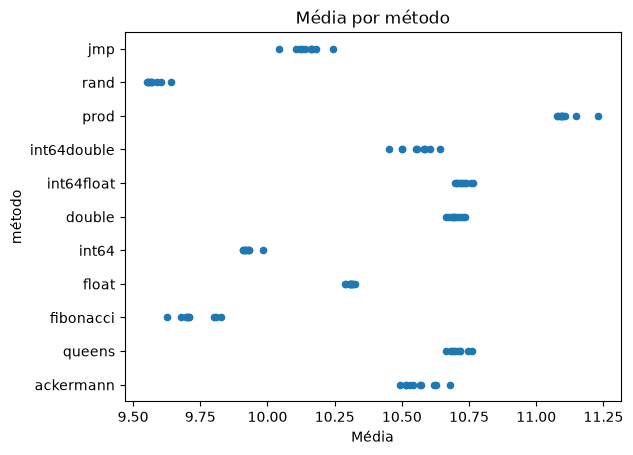

                                             Stress-ng      Média  Variância  \
0    taskset--c-0-stress-ng---cpu-1---cpu-method-ac...  10.628251   0.040359   
2    taskset--c-0-stress-ng---cpu-1---cpu-method-ac...  10.617942   0.029288   
4    taskset--c-0-stress-ng---cpu-1---cpu-method-ac...  10.513795   0.019042   
6    taskset--c-0-stress-ng---cpu-1---cpu-method-ac...  10.566973   0.028353   
8    taskset--c-0-stress-ng---cpu-1---cpu-method-ac...  10.542184   0.024126   
..                                                 ...        ...        ...   
210  taskset--c-0-stress-ng---cpu-1---cpu-method-jm...  10.180509   0.030261   
212  taskset--c-0-stress-ng---cpu-1---cpu-method-jm...  10.104244   0.021384   
214  taskset--c-0-stress-ng---cpu-1---cpu-method-jm...  10.122780   0.021512   
216  taskset--c-0-stress-ng---cpu-1---cpu-method-jm...  10.140291   0.020899   
218  taskset--c-0-stress-ng---cpu-1---cpu-method-jm...  10.244430   0.030961   

        método            cpu tempo    

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


cons = pd.read_csv("log_residual_com_frequency_demand.csv",
                   names=["Stress-ng", "Média", "Variância"])
#ons = pd.read_csv("log_medicao_paralela.csv", names=["Stress-ng", "Média", "Variância"])

'''cons = cons.rename(columns={
    "stress-ng---cpu-6---cpu-method-queens--t-30-20260924_121141.csv": "Stress-ng",
    "24.4723993227684": "Info",
    "0.008322237037118985": "Média"
    })
'''

#print(cons.columns)

#cons = cons[~cons.astype(str).apply(lambda linha : linha.str.contains("n"),any(), axis=1)]

filtrado = cons.copy()

filtrado = filtrado.dropna(subset=["Variância"])

filtrado['método'] = filtrado['Stress-ng'].str.extract(r'-method-([^-]+)')

filtrado['cpu'] = filtrado["Stress-ng"].str.split('--').str[1]

filtrado['tempo'] = filtrado['Stress-ng'].str.extract(r't-([^-]+)')
#tempo = filtrado["Stress-ng"].str.split('--').str[3]
#filtrado['tempo'] = tempo.str.split('-').str[1]

filtrado['data'] = filtrado['Stress-ng'].str.extract(r't-30-([^-]+)')
#data = filtrado["Stress-ng"].str.split('-').str[14]
#filtrado["data"] = data.str.split('_').str[0]

grupo = filtrado.groupby("método")["Média"]
#variância = grupo.var()


repres = filtrado.plot(x="Média", y="método", kind="scatter", title="Média por método")



plt.show()
print(filtrado)
filtrado.to_csv("media_residual_ondemand.csv")
#print(variância)


In [5]:
#agrega as 10 execucoes de cada metodo em uma linha so.
#o desvio que importa e a dispersao ENTRE execucoes: ela ja contem o ruido
#intra-janela, porque cada media e ela mesma uma media de 10 amostras.
#desvio_intra_medio NAO e barra de erro - e o teste do criterio de 2 W do artigo
agregado = filtrado.groupby("método").agg(
    media_agregada=("Média", "mean"),
    desvio_entre_execucoes=("Média", "std"),
    erro_padrao=("Média", "sem"),
    desvio_intra_medio=("Variância", "mean"),
    execucoes=("Média", "size"),
)

agregado = agregado.sort_values("media_agregada").reset_index()

print(agregado.round(4).to_string(index=False))


     método  media_agregada  desvio_entre_execucoes  erro_padrao  desvio_intra_medio  execucoes
       rand          9.5762                  0.0284       0.0090              0.0133         10
  fibonacci          9.7256                  0.0644       0.0204              0.0193         10
      int64          9.9271                  0.0216       0.0068              0.0124         10
        jmp         10.1452                  0.0531       0.0168              0.0228         10
      float         10.3083                  0.0115       0.0036              0.0120         10
int64double         10.5559                  0.0563       0.0178              0.0171         10
  ackermann         10.5661                  0.0593       0.0188              0.0248         10
     double         10.6993                  0.0229       0.0072              0.0101         10
     queens         10.7065                  0.0297       0.0094              0.0114         10
 int64float         10.7262             